In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/bank.csv")

### Data Extraction
We will take a look at the data overview and load into pandas dataframe.
We will take a look at all the fields, some stats of the data points, and handle missing/null values
We will also do some Feature engineering

In [4]:
#Look at head of data and columns

#top 5 rows of dataframe
print(f"{df.head()}\n\n")

#View column names
print(df.columns, '\n\n')

#shape of data row x columns
print(df.shape, '\n\n')


   age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day month  duration  campaign  pdays  previous poutcome deposit  
0    5   may      1042         1     -1         0  unknown     yes  
1    5   may      1467         1     -1         0  unknown     yes  
2    5   may      1389         1     -1         0  unknown     yes  
3    5   may       579         1     -1         0  unknown     yes  
4    5   may       673         2     -1         0  unknown     yes  


Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'con

In [5]:

#see datatypes
df.info()

df.isna().sum()

df.drop_duplicates()

df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


(11162, 17)

Here is the data overview, what was inferred from the data description above along with descriptions from kaggle

Columns:
| Variable Name | Role | Type | Demographic | Description | Units | Missing Values |
|---|---|---|---|---|---|---|
| age | Feature | Numeric | Age |  |  | no |
| job | Feature | Categorical | Occupation | type of job (categorical: "admin.","unknown","unemployed","management","housemaid","entrepreneur","student","blue-collar","self-employed","retired","technician","services") |  | no |
| marital | Feature | Categorical | Marital Status | marital status (categorical: "married","divorced","single"; note: "divorced" means divorced or widowed) |  | no |
| education | Feature | Categorical | Education Level | education level (categorical: "unknown","secondary","primary","tertiary") |  | no |
| default | Feature | Binary |  | has credit in default? (binary: "yes","no") |  | no |
| balance | Feature | Numeric |  | average yearly balance | euros | no |
| housing | Feature | Binary |  | has housing loan? (binary: "yes","no") |  | no |
| loan | Feature | Binary |  | has personal loan? (binary: "yes","no") |  | no |
| contact | Feature | Categorical |  | contact communication type (categorical: "unknown","telephone","cellular") |  | no |
| day | Feature | Numeric |  | last contact day of the month |  | no |
| month | Feature | Categorical |  | last contact month of year (categorical: "jan","feb","mar",...,"nov","dec") |  | no |
| duration | Feature | Numeric |  | last contact duration | seconds | no |
| campaign | Feature | Numeric |  | number of contacts performed during this campaign and for this client |  | no |
| pdays | Feature | Numeric |  | number of days since client was last contacted from a previous campaign (-1 means not previously contacted) |  | no |
| previous | Feature | Numeric |  | number of contacts performed before this campaign and for this client |  | no |
| poutcome | Feature | Categorical |  | outcome of the previous marketing campaign (categorical: "unknown","other","failure","success") |  | no |
| y | Target | Binary |  | has the client subscribed a term deposit? (binary: "yes","no") |  | no |


Unfortunately this dataset is pure with no missing/naN values in the dataset. We have 7 integer columns and 10 categorical columns. Next we will dive into some analytics and statistical values of the data.

Lets now dive into the Exploratory data analysis to get more statistical descriptions and see patterns in the data


In [6]:
# We will first see the numerical columns

df.describe()


,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


Looking at the data desciption above we can gather some takeaways from what the data is showing us.

1) Paydays we have some outliers, we can tell because the min, 25%, 50% is all -1.0 then the 75 and max is 20.75 - 854. Showing there is some skewness to this column and we have some outliers. The outliers are skewing the mean and the std for this column. You can futher notice this by the 108 std, showing higher variablity in the data. As we look at graphs we can visually see this.

2) Duration also has outliers that are skewing the std the mean is 371 and the std is 347.12 which shows the typical distance from the mean value. Looking at the percentiles [138,255,496] with a min of 2 and max of 3881, it looks like we have some outliers on the higher end, we may need to trim this column.


Now lets take a look at some graphs to help us paint a picture of the numerical data relations

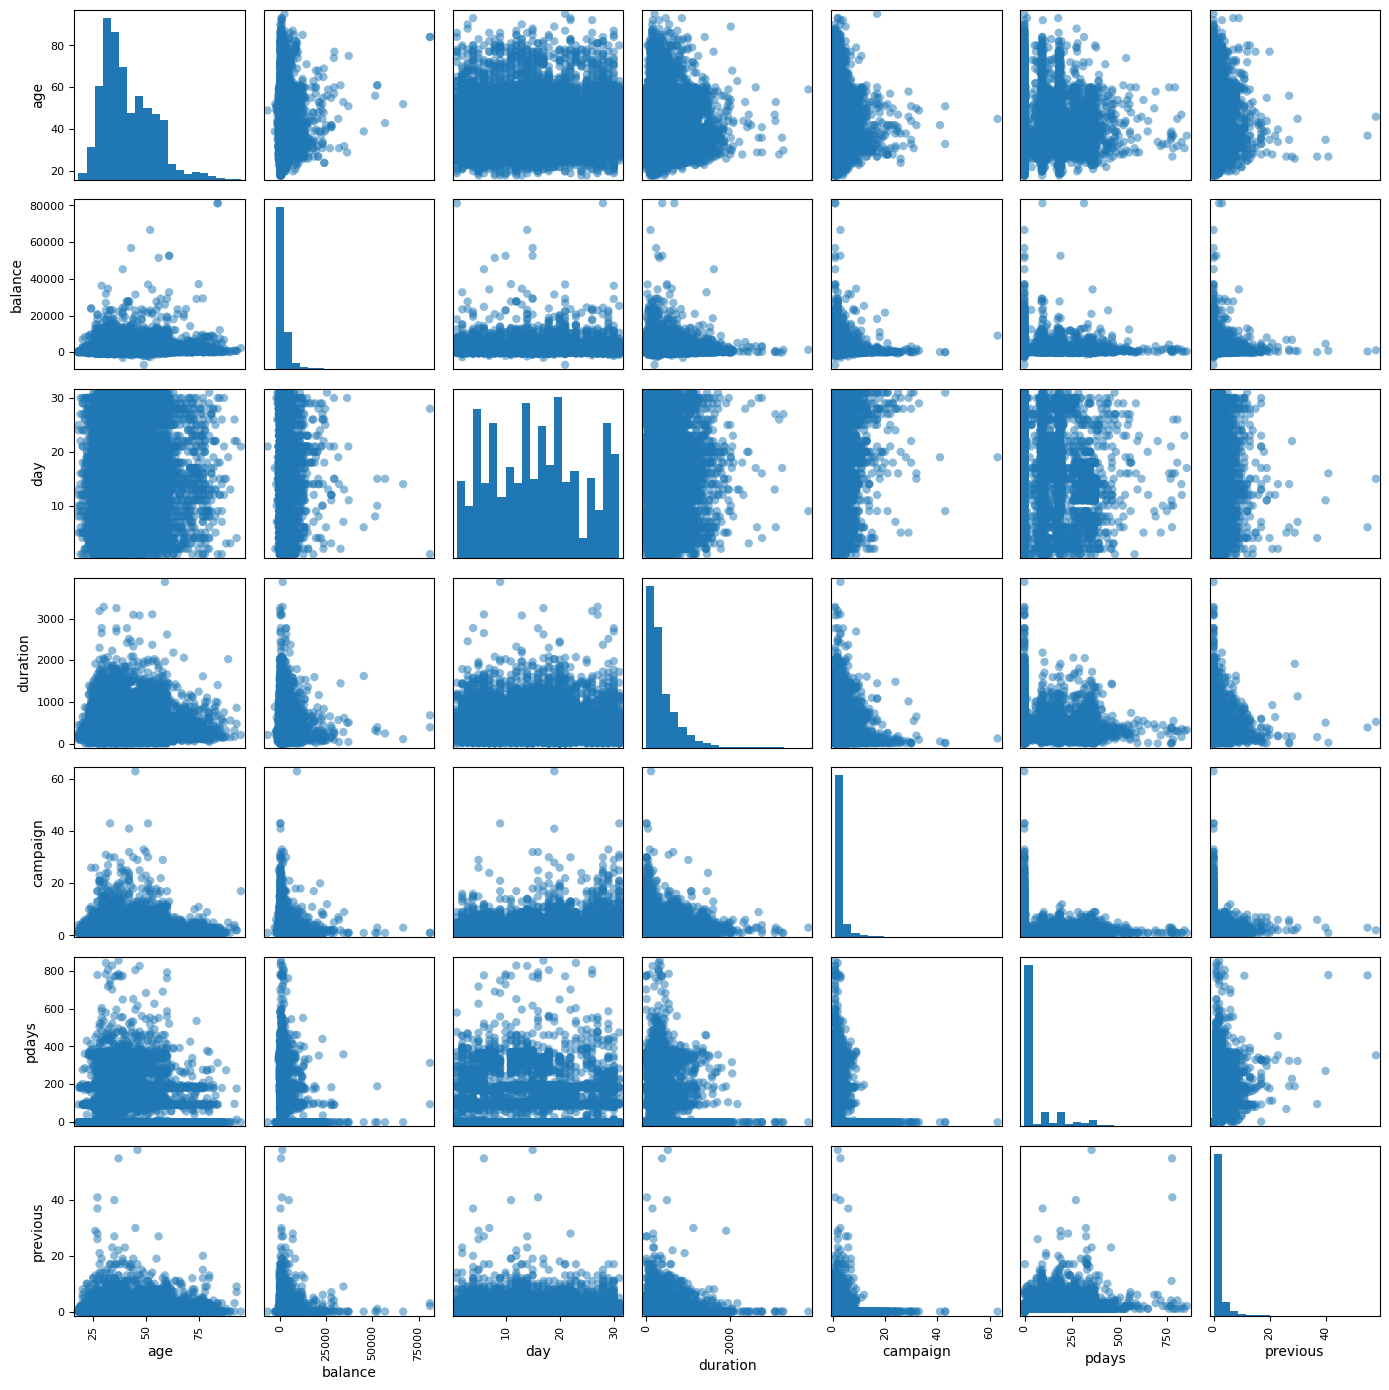

In [34]:
num_cols = df.select_dtypes(include=np.number).columns

# scatter matrix / pairwise grid
pd.plotting.scatter_matrix(
    df[num_cols],
    figsize=(14, 14),
    diagonal='hist',
    alpha=0.5,
    marker='o',
    hist_kwds={'bins': 20}
)
plt.tight_layout()
plt.show()

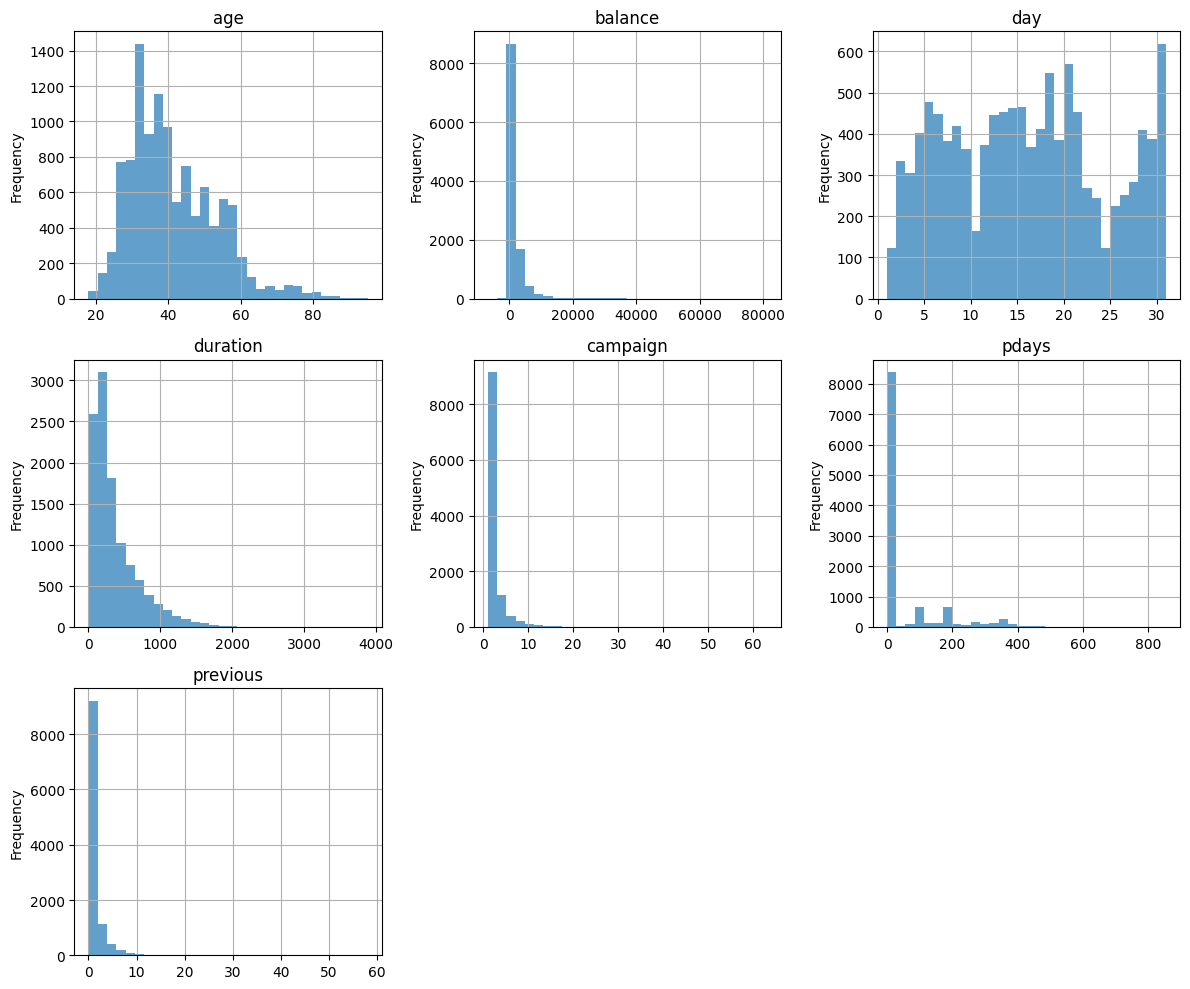

In [35]:
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    df[col].plot.hist(ax=ax, bins=30, title=col, alpha=0.7)
    ax.grid(True)

for ax in axes[len(num_cols):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

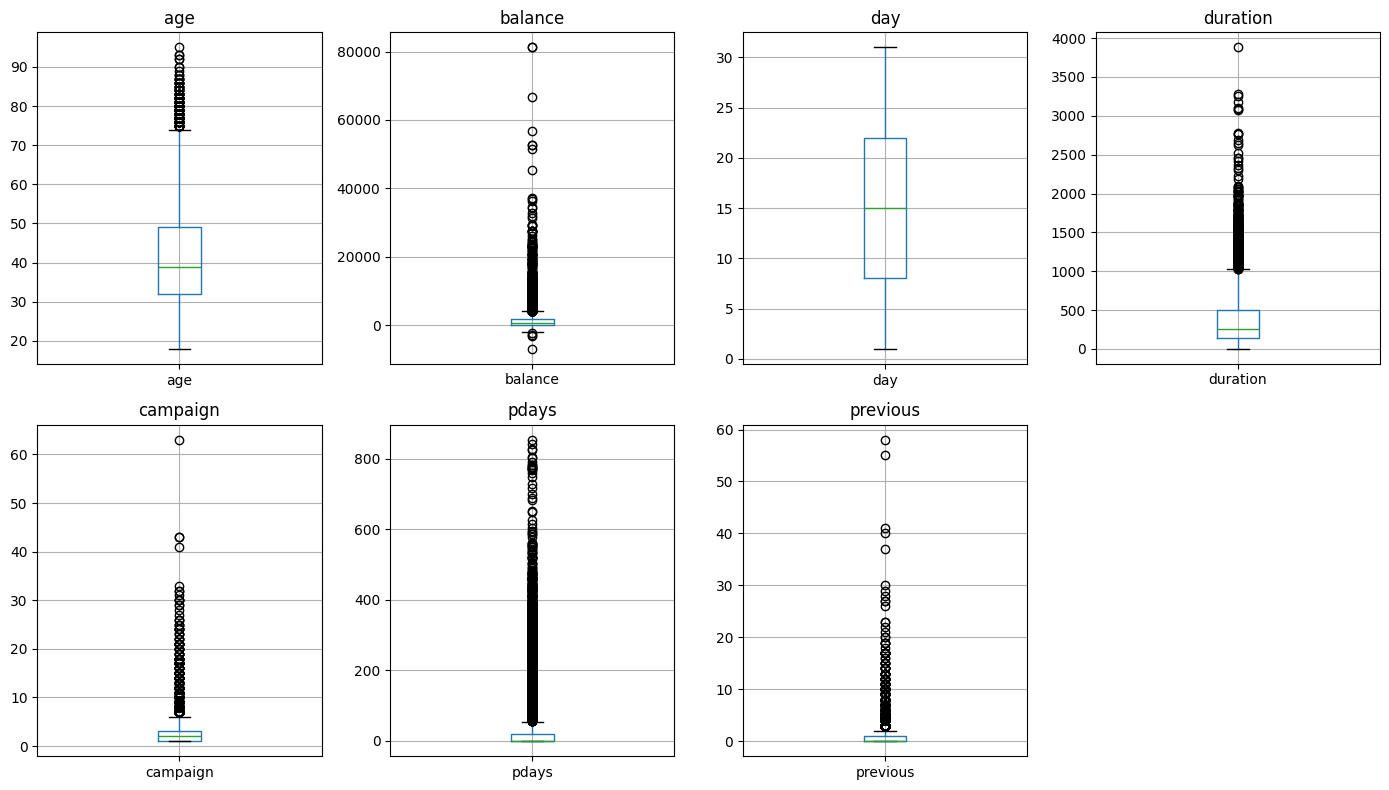

In [37]:
fig, axes = plt.subplots(2, 4, figsize=(14, 8))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    df.boxplot(column=col, ax=ax, grid=True)
    ax.set_title(col)
    ax.set_xlabel("")

for ax in axes[len(num_cols):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

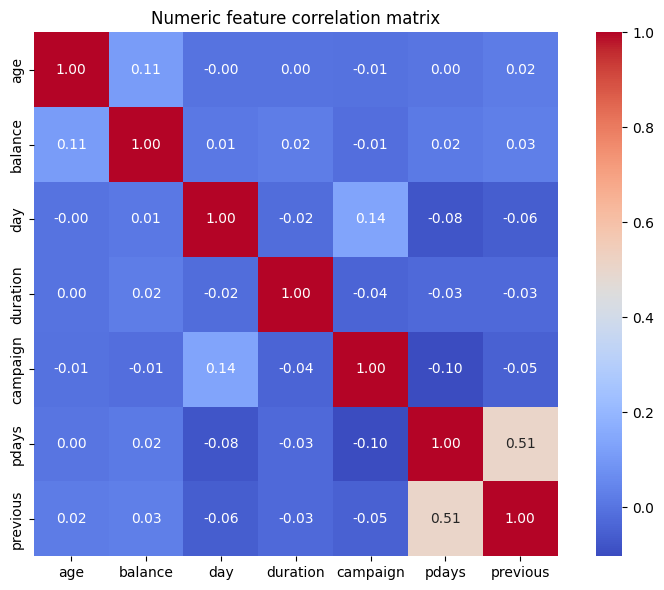

In [41]:
import seaborn as sns
num_cols = df.select_dtypes(include=np.number).columns

# correlation matrix
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, ax=ax)
plt.title("Numeric feature correlation matrix")
plt.tight_layout()
plt.show()

In [7]:
#See the category and object column descriptions

df.describe(include=['object','category'])

,job,marital,education,default,housing,loan,contact,month,poutcome,deposit
count,11162,11162,11162,11162,11162,11162,11162,11162,11162,11162
unique,12,3,4,2,2,2,3,12,4,2
top,management,married,secondary,no,no,no,cellular,may,unknown,no
freq,2566,6351,5476,10994,5881,9702,8042,2824,8326,5873


Here we get a look at the desciptions of the categorical columns

- Job
- Marital
- Education
- Default
- Housing
- Loan
- Contact
- Month

Here are some conclusions you can see in the data provided from df.describe():

1) Of 11162 rows, 6351 responses are mamrried
2) There are 12 job titles with 2566 being in managment
3) 4 values of education with 5476 finishing secondary education
4) Overwhelming majority of default fields have no (10994)
5) Housing has split about 50% yes and no 
6) Majority ve personal loans 9702
7) poutcome has many unknowns, meaning they did not have previous marketing campaigns or we do not know the result. May be worth dropping? 
8) deposit is pretty even around 50% are no, rest are yes


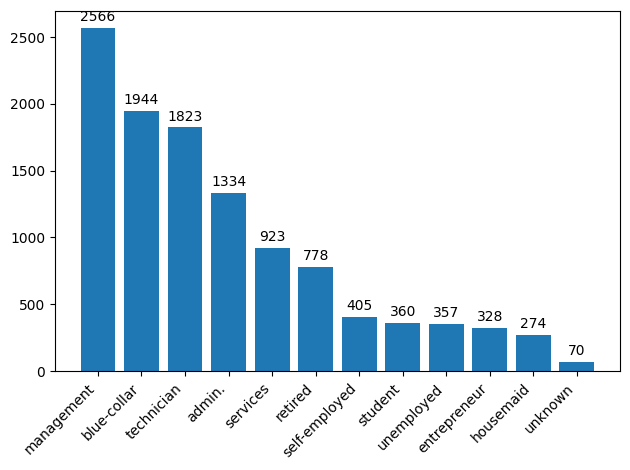

In [21]:
counts = df['job'].value_counts()
fig, ax = plt.subplots()
bars = ax.bar(counts.index, counts.values)
ax.bar_label(bars, padding=3)
ax.set_xticks(counts.index)
ax.set_xticklabels(counts.index, rotation=45, ha='right')
plt.tight_layout()
plt.show()

C:\Users\brian\AppData\Local\Temp\ipykernel_22908\3036535730.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(counts.index, rotation=45, ha='right')


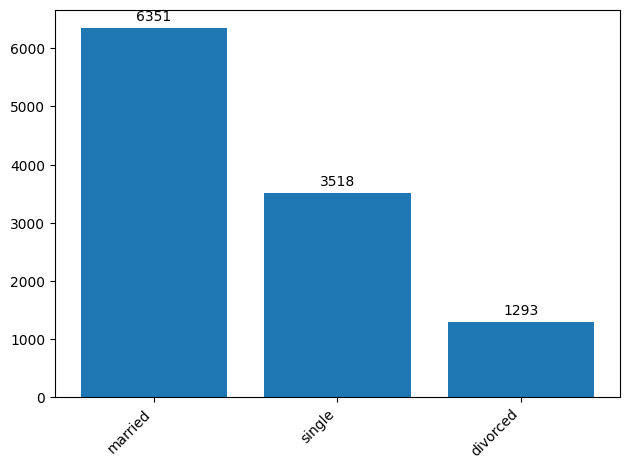

In [23]:
counts = df['marital'].value_counts()
fig, ax = plt.subplots()
bars = ax.bar(counts.index, counts.values)
ax.bar_label(bars, padding=3)
ax.set_xticklabels(counts.index, rotation=45, ha='right')
plt.tight_layout()
plt.show()

C:\Users\brian\AppData\Local\Temp\ipykernel_22908\3622464619.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(counts.index, rotation=45, ha='right')


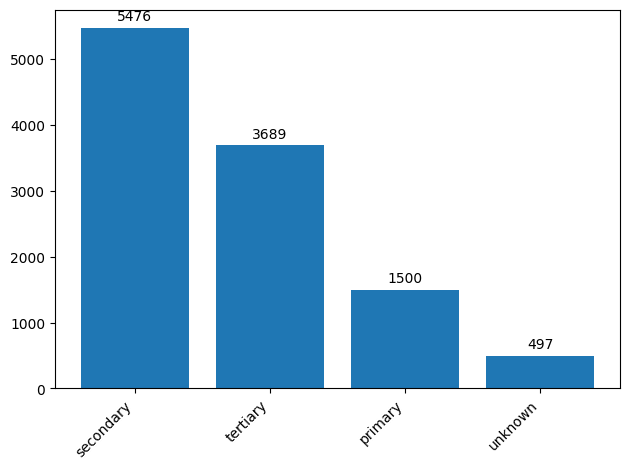

In [24]:
counts = df['education'].value_counts()
fig, ax = plt.subplots()
bars = ax.bar(counts.index, counts.values)
ax.bar_label(bars, padding=3)
ax.set_xticklabels(counts.index, rotation=45, ha='right')
plt.tight_layout()
plt.show()

C:\Users\brian\AppData\Local\Temp\ipykernel_22908\2617826683.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(counts.index, rotation=45, ha='right')


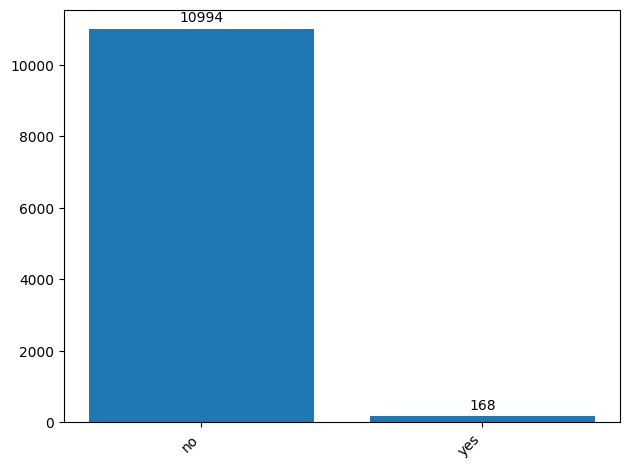

In [25]:
counts = df['default'].value_counts()
fig, ax = plt.subplots()
bars = ax.bar(counts.index, counts.values)
ax.bar_label(bars, padding=3)
ax.set_xticklabels(counts.index, rotation=45, ha='right')
plt.tight_layout()
plt.show()

C:\Users\brian\AppData\Local\Temp\ipykernel_22908\3887421179.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(counts.index, rotation=45, ha='right')


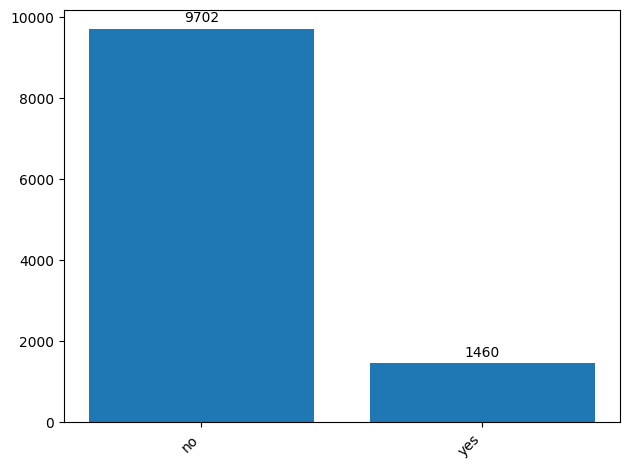

In [26]:
counts = df['loan'].value_counts()
fig, ax = plt.subplots()
bars = ax.bar(counts.index, counts.values)
ax.bar_label(bars, padding=3)
ax.set_xticklabels(counts.index, rotation=45, ha='right')
plt.tight_layout()
plt.show()

C:\Users\brian\AppData\Local\Temp\ipykernel_22908\2759754024.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(counts.index, rotation=45, ha='right')


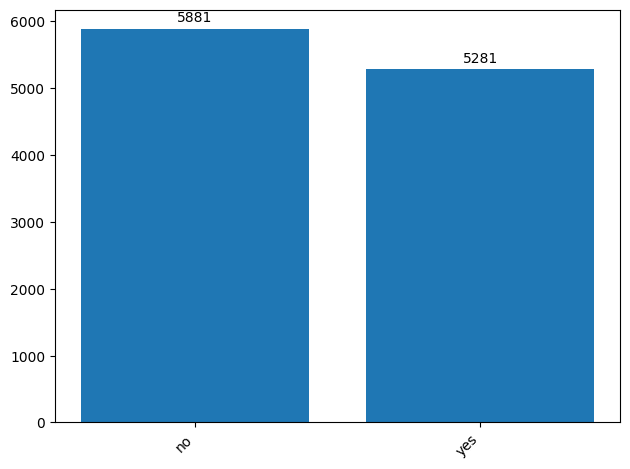

In [27]:
counts = df['housing'].value_counts()
fig, ax = plt.subplots()
bars = ax.bar(counts.index, counts.values)
ax.bar_label(bars, padding=3)
ax.set_xticklabels(counts.index, rotation=45, ha='right')
plt.tight_layout()
plt.show()

C:\Users\brian\AppData\Local\Temp\ipykernel_22908\3963943070.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(counts.index, rotation=45, ha='right')


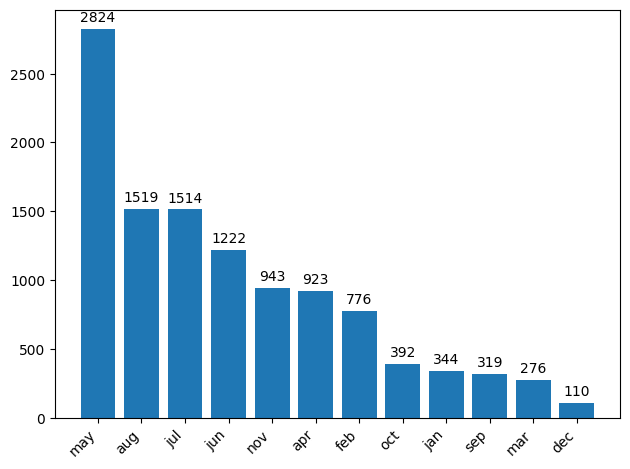

In [28]:
counts = df['month'].value_counts()
fig, ax = plt.subplots()
bars = ax.bar(counts.index, counts.values)
ax.bar_label(bars, padding=3)
ax.set_xticklabels(counts.index, rotation=45, ha='right')
plt.tight_layout()
plt.show()

C:\Users\brian\AppData\Local\Temp\ipykernel_22908\1743772912.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(counts.index, rotation=45, ha='right')


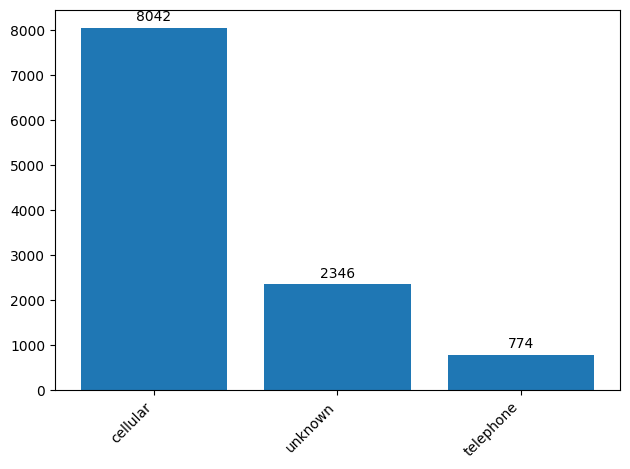

In [29]:
counts = df['contact'].value_counts()
fig, ax = plt.subplots()
bars = ax.bar(counts.index, counts.values)
ax.bar_label(bars, padding=3)
ax.set_xticklabels(counts.index, rotation=45, ha='right')
plt.tight_layout()
plt.show()